In [1]:
## === Standard Startup Template ===
import os, random
import numpy as np
import torch
import lpips

# --- Project Path Setup ---
root        = r"C:\AI_research"
dataset_dir = os.path.join(root, "dataset", "train_colored")
output_dir  = os.path.join(root, "outputs", "blurred_test")
ckpt_dir    = os.path.join(root, "outputs", "checkpoints")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

# --- Device Setup ---
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# --- Reproducibility Setup ---
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False

print(f"Reproducibility mode ON (seed = {seed})")

# --- Constants ---
img_size   = 256
batch_size = 4
fraunhofer = "diamond"  # None(gaussian) | "circle" | "triangle" | "diamond"


PyTorch version: 2.8.0+cu128
Using device: cuda
CUDA device: NVIDIA GeForce RTX 4060 Ti
Reproducibility mode ON (seed = 42)


In [2]:
##Dataset Class + Modular Blur Function
import os
import cv2
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# === Modular Blur Function ===
def apply_per_channel_blur(img, blur_kernels):
    img = img.astype(np.float32) / 255.0
    channels = cv2.split(img)

    blurred = []
    for ch, name in zip(channels, ['R', 'G', 'B']):
        kernel = blur_kernels[name]

        if isinstance(kernel, tuple):  # Gaussian blur
            ksize, sigma = kernel
            ch_blurred = cv2.GaussianBlur(ch, (ksize, ksize), sigma)
        else:  # Real PSF (2D numpy array)
            ch_blurred = cv2.filter2D(ch, -1, kernel)

        blurred.append(ch_blurred)

    return cv2.merge(blurred)

# === PyTorch Dataset Class ===
class SharpSignageDataset(Dataset):
    def __init__(self, img_dir, img_size=256):
        # Only need sharp image paths
        self.img_paths = [
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if f.lower().endswith(".png")
        ]
        self.img_size = img_size
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Load and preprocess sharp image
        img = cv2.imread(self.img_paths[idx], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        sharp_tensor = self.to_tensor(img)
        return sharp_tensor

In [3]:
### Set Blur Kernels + Create Dataset

# Use a common sigma for all channels so all kernels have the same size
common_sigma = 1.0
blur_sigmas = {ch: common_sigma for ch in ['R','G','B']}

# === Load your dataset ===
img_dir = dataset_dir

# Note: SharpSignageDataset now only needs img_dir and img_size
dataset = SharpSignageDataset(img_dir, img_size=256)

In [4]:
###Create DataLoader + Inspect
from torch.utils.data import DataLoader, random_split

# Assume `dataset` is your SharpSignageDataset that only returns sharp tensors
# 90/10 train–val split
train_size = int(0.9 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# Create loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

# Quick sanity check: each batch is just the sharp input
for batch in train_loader:
    print("Batch shape (sharp):", batch.shape)  # should be (B, 3, 256, 256)
    break

Batch shape (sharp): torch.Size([32, 3, 256, 256])


In [5]:
###Kernel Generator fot pythorch
import torch
import torch.nn.functional as F
import math

def create_gaussian_kernel(sigma, tol=1e-6):
    # 1) compute odd ksize ≃ ⌈8σ⌉
    k = math.ceil(8 * sigma)
    if k % 2 == 0:
        k += 1

    # 2) sample the 2D Gaussian
    ax = torch.arange(k, device=device) - k//2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    raw = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # 3) normalize and assert sum = 1
    kernel = raw / raw.sum()
    s = float(kernel.sum())
    assert abs(s - 1.0) < tol, f"Kernel sum {s:.6f} ≠ 1 (σ={sigma})"

    return k,  kernel

In [6]:
###Build Per-Channel Kernels for F.conv2d
def build_blur_kernels(blur_sigmas):
    kernels = []
    
    # --- THE FIX IS HERE ---
    # Directly loop over the sigma values in the dictionary
    for sigma in blur_sigmas.values():
        
        # Unpack the tuple, assigning the size to '_' (to ignore it) 
        # and the tensor to 'k'.
        _, k = create_gaussian_kernel(sigma)
        
        k_tensor = k.unsqueeze(0).unsqueeze(0)     # [1,1,k,k]
        kernels.append(k_tensor)
        
    return torch.cat(kernels, dim=0)

In [7]:
###Differentiable Reblur Function
import torch.nn.functional as F

def reblur_tensor(image_tensor, kernel_tensor):
    """
    image_tensor: [B, 3, H, W]
    kernel_tensor: [3, 1, k, k]
    """
    B, C, H, W = image_tensor.shape
    k = kernel_tensor.shape[-1]

    # Expand kernels for grouped convolution
    kernel = kernel_tensor.to(image_tensor.device)             # [3, 1, k, k]

    # Apply per-channel blur using groups=3
    return F.conv2d(image_tensor, kernel, padding=k//2, groups=3)


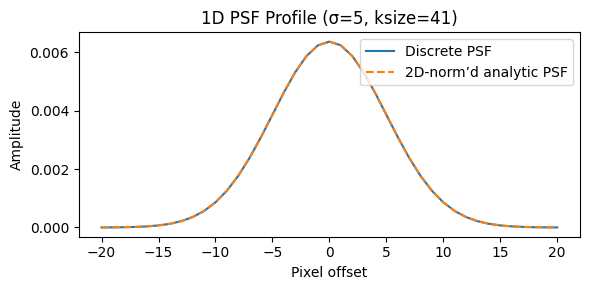

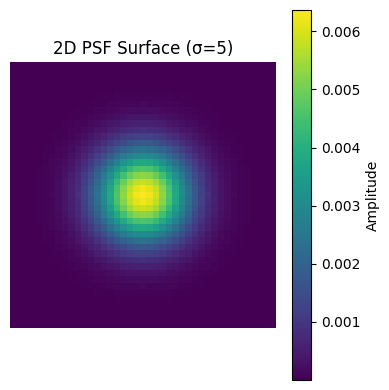

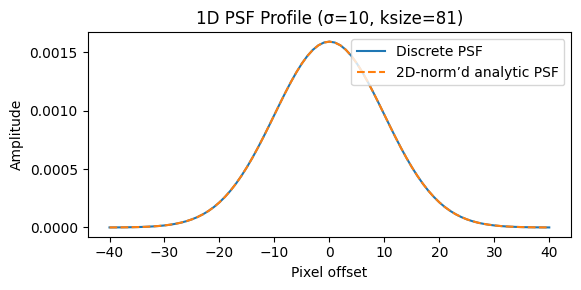

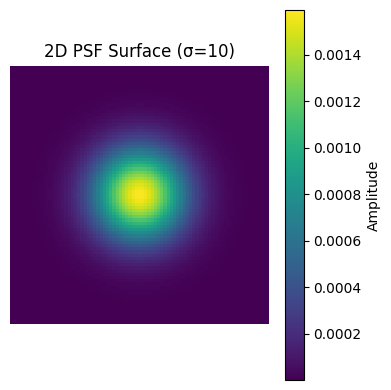

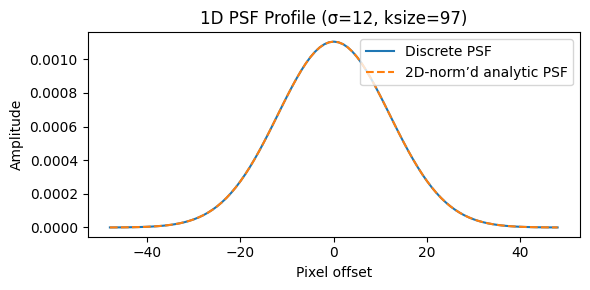

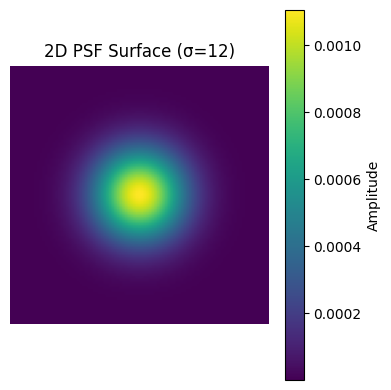

In [8]:
# Cell 4 (updated continuous normalization)
import matplotlib.pyplot as plt
import numpy as np

visual_sigmas = [5, 10, 12]          # ← pick the σ-values to plot

for sigma in visual_sigmas:
    ksize, kernel = create_gaussian_kernel(sigma)
    k = kernel if isinstance(kernel, np.ndarray) else kernel.cpu().numpy()
    center = ksize // 2
    x = np.arange(-center, center+1)

    # --- build & normalize the *2D* continuous Gaussian ---
    ax = x
    xx, yy = np.meshgrid(ax, ax)
    raw2d = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    raw2d /= raw2d.sum()

    # --- extract the 1D profile from the 2D Gaussian ---
    cont_profile = raw2d[center, :]

    # Plot
    plt.figure(figsize=(6,3))
    plt.plot(x, k[center, :],         label="Discrete PSF")
    plt.plot(x, cont_profile, "--",   label="2D-norm’d analytic PSF")
    plt.title(f"1D PSF Profile (σ={sigma}, ksize={ksize})")
    plt.xlabel("Pixel offset"); plt.ylabel("Amplitude")
    plt.legend(); plt.tight_layout(); plt.show()

    # (2D surface plot stays the same)
    plt.figure(figsize=(4,4))
    plt.imshow(k, origin="lower")
    plt.title(f"2D PSF Surface (σ={sigma})")
    plt.colorbar(label="Amplitude"); plt.axis("off"); plt.tight_layout()
    plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualUNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()

        # -------- encoder --------
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch,   base, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base,    base, 3, padding=1), nn.ReLU(inplace=True)
        )
        self.down1 = nn.MaxPool2d(2)                    # 1/2

        self.enc2 = nn.Sequential(
            nn.Conv2d(base,  base*2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*2,base*2, 3, padding=1), nn.ReLU(inplace=True)
        )
        self.down2 = nn.MaxPool2d(2)                    # 1/4

        # -------- bottleneck --------
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base*2, base*4, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*4, base*4, 3, padding=1), nn.ReLU(inplace=True)
        )

        # -------- decoder --------
        self.up2   = nn.Upsample(scale_factor=2, mode='nearest')  # 1/2
        self.dec2  = nn.Sequential(
            nn.Conv2d(base*4+base*2, base*2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*2,        base*2, 3, padding=1), nn.ReLU(inplace=True)
        )

        self.up1   = nn.Upsample(scale_factor=2, mode='nearest')  # back to 1×
        self.dec1  = nn.Sequential(
            nn.Conv2d(base*2+base, base, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base,        base, 3, padding=1), nn.ReLU(inplace=True)
        )

        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)      # no activation

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        b  = self.bottleneck(self.down2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        resid = self.out_conv(d1)          # high-frequency boost
        out   = torch.clamp(x + resid, 0., 1.)  # residual skip, keep values valid
        return out


In [10]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics.functional import structural_similarity_index_measure as ssim
import torch.nn.functional as F

# === Create the model ===
model = ResidualUNet().to(device)

# === Define the loss function ===
def hybrid_loss_with_lpips(pred, target, lpips_net, mse_weight=0.80, ssim_weight=0.10, lpips_weight=0.10, color_weight=0.1):
    """
    Calculates a hybrid loss including MSE, SSIM, LPIPS, and a color consistency term.
    """
    # --- MSE Loss ---
    mse = F.mse_loss(pred, target)

    # --- SSIM Loss ---
    ssim_val = ssim(pred, target, data_range=1.0, size_average=True)
    ssim_loss = 1.0 - ssim_val

    # --- LPIPS Loss ---
    lpips_loss = lpips_net(pred, target).mean()

    # --- Color Consistency Loss ---
    color_loss = color_consistency_loss(pred, target)

    # --- Combined Loss ---
    loss = (mse_weight * mse) + (ssim_weight * ssim_loss) + (lpips_weight * lpips_loss) + (color_weight * color_loss)
    
    return loss, mse, ssim_loss, lpips_loss, color_loss
    
# === Choose the optimizer ===
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("✅ Model ready on:", device)


✅ Model ready on: cuda


In [11]:
# Rebuild the differentiable kernel tensor
kernel_tensor = build_blur_kernels(blur_sigmas).to(device)

In [12]:
# === Use Differnt PSF =================================
# Create Seperate synthetic kenrels using Fraunhofer diffraction
# It creates a grouped conv2d kernel: (C,1,H,W) so each channel uses the same PSF by default.
# === Dependencies ===
import numpy as np
import torch
import torch.nn.functional as F

# ================= Supersampling helpers (anti-aliased apertures) =================
def _downsample_mean(img_hr, ss: int):
    Hh, Wh = img_hr.shape
    H, W = Hh // ss, Wh // ss
    return img_hr.reshape(H, ss, W, ss).mean(axis=(1, 3))

def aperture_circle_supersampled(shape=(256,256), radius_px=36, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh]
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0
    r2 = (yy-cy)**2 + (xx-cx)**2
    mask_hr = (r2 <= (radius_px*ss)**2).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

def aperture_equilateral_triangle_supersampled(shape=(256,256), side_px=120, rotate_deg=0.0, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh].astype(np.float64)
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0

    a = side_px * ss
    h = np.sqrt(3.0)/2.0 * a
    v1 = np.array([cy - 2*h/3.0, cx])          # top
    v2 = np.array([cy +   h/3.0, cx - a/2.0])  # bottom-left
    v3 = np.array([cy +   h/3.0, cx + a/2.0])  # bottom-right

    th = np.deg2rad(rotate_deg)
    R  = np.array([[np.cos(th), -np.sin(th)],
                   [np.sin(th),  np.cos(th)]])
    C  = np.array([cy, cx])
    def rot(v): return (R @ (v - C)) + C
    v1, v2, v3 = rot(v1), rot(v2), rot(v3)

    P = np.stack([yy, xx], axis=-1)
    def hp(p, a, b):  # half-plane test for CCW vertices
        return (b[0]-a[0])*(p[...,1]-a[1]) - (b[1]-a[1])*(p[...,0]-a[0])
    mask_hr = ((hp(P, v1, v2) >= 0) & (hp(P, v2, v3) >= 0) & (hp(P, v3, v1) >= 0)).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

def aperture_diamond_supersampled(shape=(256,256), diagonal_px=160, rotate_deg=45.0, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh].astype(np.float64)
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0
    s = (diagonal_px * ss) / np.sqrt(2.0)  # square side (hi-res)
    half = s/2.0
    th = np.deg2rad(rotate_deg)
    cos_t, sin_t = np.cos(-th), np.sin(-th)
    X = (xx - cx)*cos_t - (yy - cy)*sin_t
    Y = (xx - cx)*sin_t + (yy - cy)*cos_t
    mask_hr = ((np.abs(X) <= half) & (np.abs(Y) <= half)).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

# ================= Fraunhofer PSF (|FFT{aperture}|^2), with padding =================
def fraunhofer_psf_from_aperture(aperture: np.ndarray, oversample: int = 2):
    """
    Computes intensity PSF ∝ |FFT{aperture}|^2 with zero-padding (oversample >= 1).
    Returns a unit-sum PSF.
    """
    H, W = aperture.shape
    padH, padW = int(H*oversample), int(W*oversample)
    U = np.fft.fftshift(np.fft.fft2(aperture, s=(padH, padW)))
    psf = np.abs(U)**2
    psf /= (psf.sum() + 1e-12)
    return psf

# ================= Crop PSF to an odd kernel size for conv2d =================
def crop_psf(psf: np.ndarray, kernel_size: int = 21):
    """
    Center-crops to odd size, renormalizes to unit sum.
    """
    k = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    H, W = psf.shape
    cy, cx = H//2, W//2
    half = k//2
    patch = psf[cy-half:cy+half+1, cx-half:cx+half+1].copy()
    patch /= (patch.sum() + 1e-12)
    return patch

# ================= Make grouped conv kernels (3,1,k,k), groups=3 =================
def make_fraunhofer_kernel(kind, image_shape=(256,256), kernel_size=21,
                           circ_radius_px=36, tri_side_px=120, tri_rotate_deg=0.0,
                           diamond_diag_px=160, diamond_rotate_deg=45.0,
                           ss=6, oversample=2, device="cpu"):
    """
    kind: "circle" | "triangle" | "diamond"
    Returns a Torch weight of shape (3,1,k,k) with unit sum, ready for grouped conv (groups=3).
    """
    H, W = image_shape
    if kind == "circle":
        ap = aperture_circle_supersampled((H,W), radius_px=circ_radius_px, ss=ss)
    elif kind == "triangle":
        ap = aperture_equilateral_triangle_supersampled((H,W), side_px=tri_side_px,
                                                        rotate_deg=tri_rotate_deg, ss=ss)
    elif kind == "diamond":
        ap = aperture_diamond_supersampled((H,W), diagonal_px=diamond_diag_px,
                                           rotate_deg=diamond_rotate_deg, ss=ss)
    else:
        raise ValueError("kind must be 'circle' | 'triangle' | 'diamond'")
    psf = fraunhofer_psf_from_aperture(ap, oversample=oversample)
    psf_k = crop_psf(psf, kernel_size=kernel_size)
    k = torch.from_numpy(psf_k.astype(np.float32)).to(device)
    k = k / (k.sum() + 1e-12)
    return k.unsqueeze(0).unsqueeze(0).repeat(3,1,1,1)  # (3,1,k,k)

# ================= Minimal quick checks (won't change state) =================
def _check_kernel_ok(k4d: torch.Tensor, tol=1e-4):
    """
    k4d: (C,1,k,k) repeated per channel for grouped conv.
    Validates shape (odd k), and that each channel's kernel sums to ~1.
    """
    assert k4d.ndim == 4 and k4d.shape[1] == 1 and (k4d.shape[2] % 2 == 1), "Shape/odd-size check failed"
    # Per-channel sums
    s_per = k4d.view(k4d.shape[0], -1).sum(dim=1).detach().cpu().numpy()
    for i, s in enumerate(s_per):
        assert abs(float(s) - 1.0) < tol, f"Channel {i} kernel sum {s:.6f} ≠ 1"

# Example sanity test (safe to run)
k_demo = make_fraunhofer_kernel("circle", kernel_size=21, device="cpu")
_check_kernel_ok(k_demo)

print(k_demo.shape, k_demo.sum(dim=[1,2,3]))



torch.Size([3, 1, 21, 21]) tensor([1., 1., 1.])


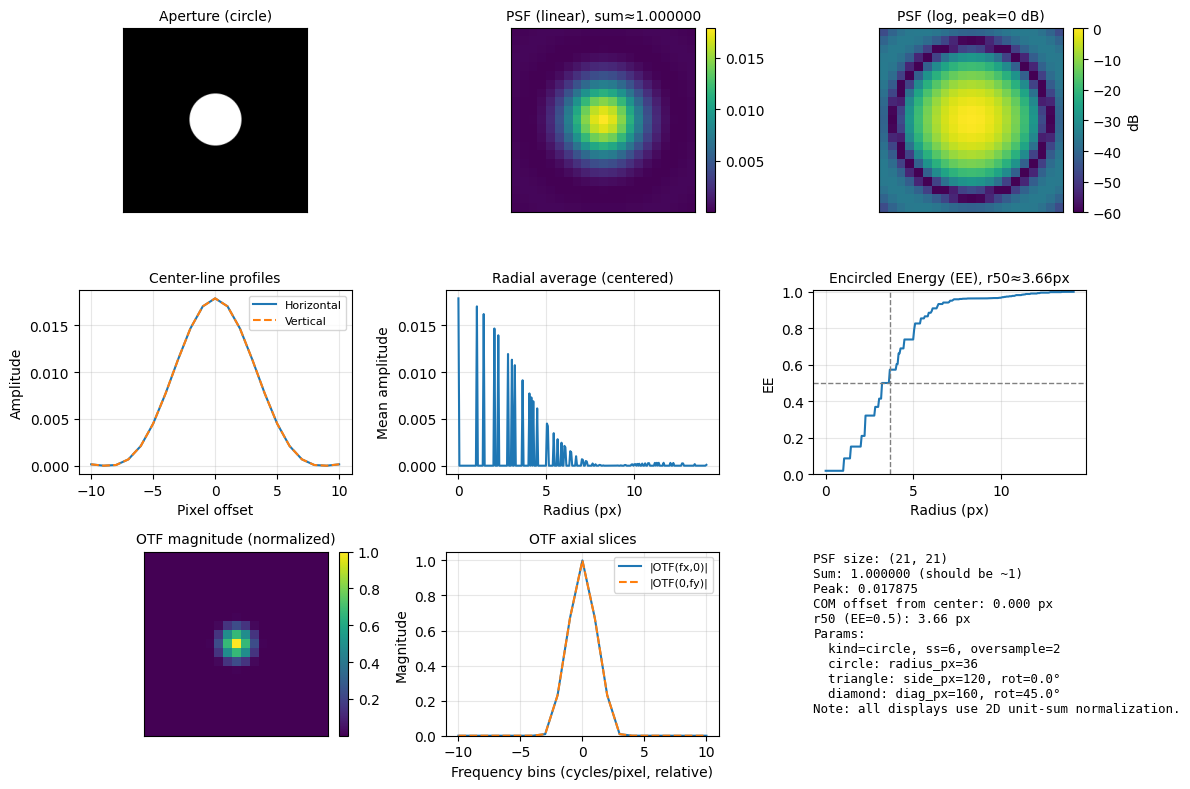

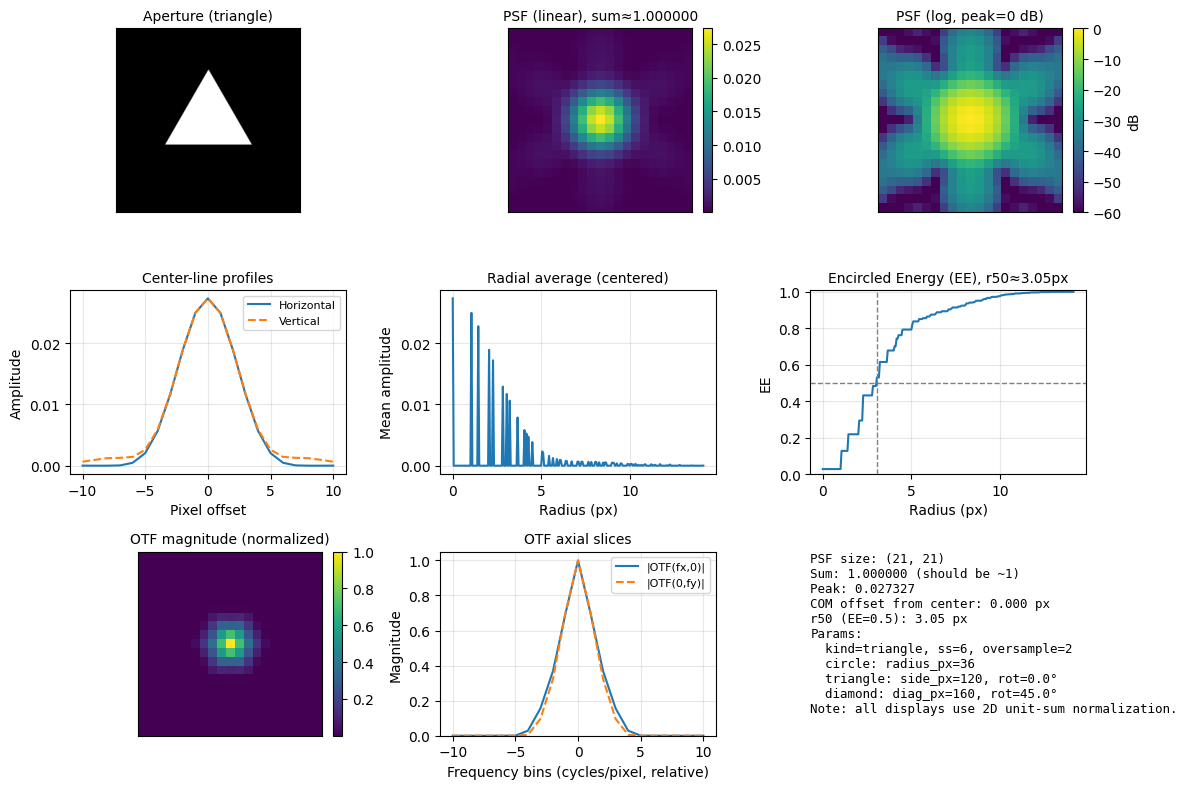

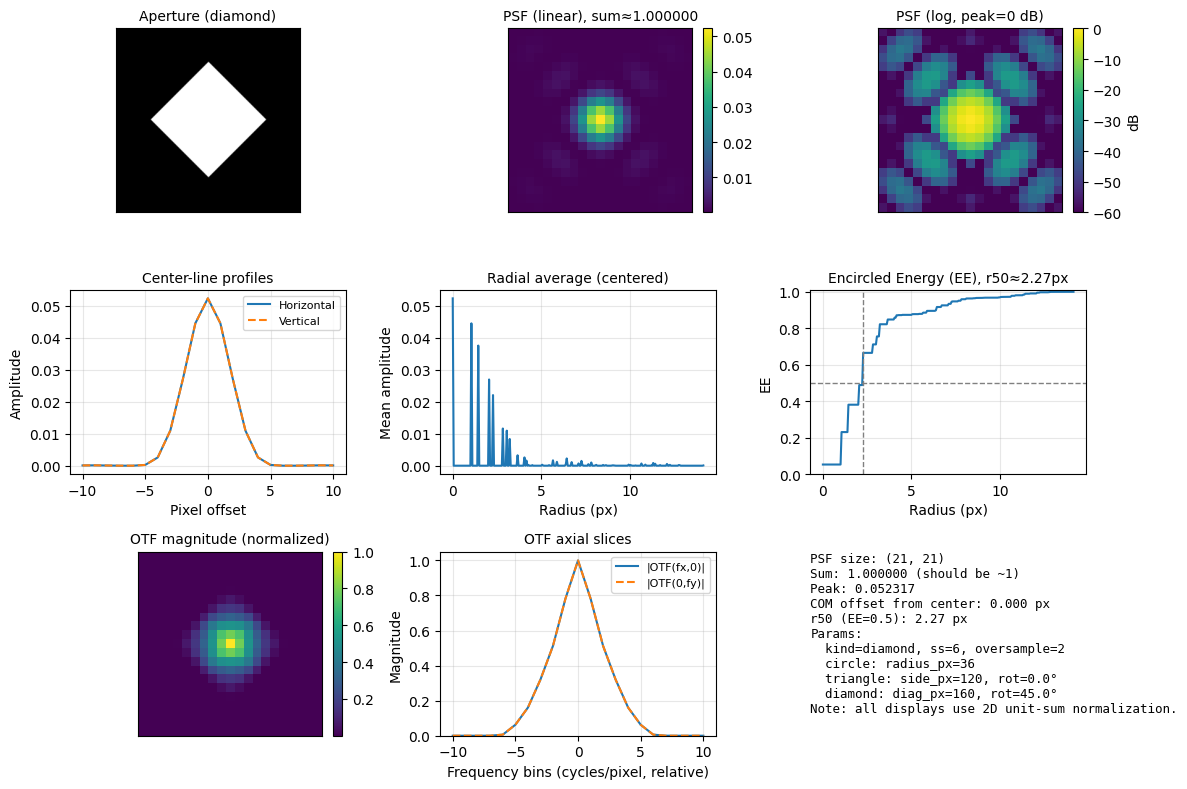

In [13]:
# ===================== Fraunhofer PSF Visualization Panel (non-breaking) =====================
# This cell adds visualization utilities. It does NOT modify your Gaussian code or training flow.

import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- Small utilities (numerical) ----------

def _center_of_mass(img):
    img = np.asarray(img, dtype=np.float64)
    total = img.sum()
    if total <= 0: 
        return np.array([(img.shape[0]-1)/2.0, (img.shape[1]-1)/2.0])
    ys, xs = np.mgrid[:img.shape[0], :img.shape[1]]
    cy = (ys*img).sum()/total
    cx = (xs*img).sum()/total
    return np.array([cy, cx])

def _encircled_energy(psf, n_r=256):
    H, W = psf.shape
    cy, cx = (H-1)/2.0, (W-1)/2.0
    ys, xs = np.mgrid[:H, :W]
    r = np.sqrt((ys-cy)**2 + (xs-cx)**2)
    r_max = r.max()
    rr = np.linspace(0, r_max, n_r)
    ee = np.zeros_like(rr)
    # cumulative by radius threshold
    flat = psf.ravel()
    rflat = r.ravel()
    order = np.argsort(rflat)
    r_sorted = rflat[order]
    psf_sorted = flat[order]
    csum = np.cumsum(psf_sorted)
    for i, rv in enumerate(rr):
        j = np.searchsorted(r_sorted, rv, side="right")
        ee[i] = csum[j-1] if j>0 else 0.0
    return rr, ee

def _radial_average(img, n_r=256):
    H, W = img.shape
    cy, cx = (H-1)/2.0, (W-1)/2.0
    ys, xs = np.mgrid[:H, :W]
    r = np.sqrt((ys-cy)**2 + (xs-cx)**2)
    r_max = r.max()
    rr = np.linspace(0, r_max, n_r)
    prof = np.zeros_like(rr)
    # bin-average
    bins = rr
    idx = np.digitize(r.ravel(), bins, right=True)
    sums = np.bincount(idx, weights=img.ravel(), minlength=len(bins)+1)
    cnts = np.bincount(idx, minlength=len(bins)+1)
    cnts[cnts == 0] = 1
    prof = (sums/cnts)[:len(rr)]
    return rr, prof

def _otf_mag(psf):
    # OTF magnitude (normalized so OTF(0,0) ≈ 1)
    otf = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(psf)))
    # normalize by DC (sum of PSF)
    dc = np.abs(otf[otf.shape[0]//2, otf.shape[1]//2])
    if dc == 0: 
        return np.abs(otf)
    return np.abs(otf) / (dc + 1e-12)

def _safe_log10(x, floor=1e-12):
    return np.log10(np.maximum(x, floor))

# ---------- Core visualization routine ----------

def show_fraunhofer_report(kind,
                           image_shape=(256,256),
                           kernel_size=21,
                           circ_radius_px=36,
                           tri_side_px=120, tri_rotate_deg=0.0,
                           diamond_diag_px=160, diamond_rotate_deg=45.0,
                           ss=6, oversample=2,
                           dB_floor=-60.0,
                           figscale=1.0):
    """
    kind: "circle" | "triangle" | "diamond"
    Produces a compact report: aperture, PSF (linear/log), 1D cuts, radial stats, OTF slices.
    Uses your existing make_fraunhofer_kernel() path to ensure consistency.
    """

    # 1) Recreate the aperture exactly as your kernel builder does (for display only)
    H, W = image_shape
    if kind == "circle":
        ap = aperture_circle_supersampled((H,W), radius_px=circ_radius_px, ss=ss)
    elif kind == "triangle":
        ap = aperture_equilateral_triangle_supersampled((H,W), side_px=tri_side_px,
                                                        rotate_deg=tri_rotate_deg, ss=ss)
    elif kind == "diamond":
        ap = aperture_diamond_supersampled((H,W), diagonal_px=diamond_diag_px,
                                           rotate_deg=diamond_rotate_deg, ss=ss)
    else:
        raise ValueError("kind must be 'circle' | 'triangle' | 'diamond'")

    # 2) PSF via Fraunhofer, then crop as per your conv kernel
    psf_full = fraunhofer_psf_from_aperture(ap, oversample=oversample)
    psf = crop_psf(psf_full, kernel_size=kernel_size)  # unit-sum ensured inside crop

    # 3) Quick stats (sanity)
    Hk, Wk = psf.shape
    cy, cx = Hk//2, Wk//2
    com = _center_of_mass(psf)
    com_off = np.sqrt(((com - np.array([cy, cx]))**2).sum())
    ksum = psf.sum()
    kmax = psf.max()
    rr, ee = _encircled_energy(psf)
    # half-energy radius (first r where EE >= 0.5)
    idx50 = np.searchsorted(ee, 0.5, side="left")
    r50 = rr[idx50] if idx50 < len(rr) else np.nan

    # 4) 1D cuts
    cut_h = psf[cy, :]
    cut_v = psf[:, cx]

    # 5) Radial average (helpful for circle; still informative for others)
    rra, prof = _radial_average(psf)

    # 6) OTF magnitude and axial slices
    otf = _otf_mag(psf)
    oy, ox = otf.shape[0]//2, otf.shape[1]//2
    otf_x = otf[oy, :]   # fx axis
    otf_y = otf[:, ox]   # fy axis

    # 7) Figure layout
    plt.figure(figsize=(12*figscale, 8*figscale))
    gs_kw = dict(width_ratios=[1,1,1], height_ratios=[1,1,1])
    import matplotlib.gridspec as gridspec
    gs = gridspec.GridSpec(3, 3, **gs_kw)

    # (1) Aperture (linear)
    ax = plt.subplot(gs[0,0])
    im = ax.imshow(ap, cmap='gray', origin='upper')
    ax.set_title(f"Aperture ({kind})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])


    # (2) PSF linear
    ax = plt.subplot(gs[0,1])
    im = ax.imshow(psf, cmap='viridis', origin='upper')
    ax.set_title(f"PSF (linear), sum≈{ksum:.6f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (3) PSF log (dB)
    ax = plt.subplot(gs[0,2])
    log_db = 20.0 * _safe_log10(psf / (kmax + 1e-12))
    im = ax.imshow(np.clip(log_db, dB_floor, 0), cmap='viridis', origin='upper',
                   vmin=dB_floor, vmax=0)
    ax.set_title(f"PSF (log, peak=0 dB)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("dB")

    # (4) Axial cuts (H & V)
    ax = plt.subplot(gs[1,0])
    ax.plot(np.arange(Wk)-cx, cut_h, label='Horizontal')
    ax.plot(np.arange(Hk)-cy, cut_v, label='Vertical', linestyle='--')
    ax.set_title("Center-line profiles", fontsize=10)
    ax.set_xlabel("Pixel offset"); ax.set_ylabel("Amplitude")
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    # (5) Radial average
    ax = plt.subplot(gs[1,1])
    ax.plot(rra, prof)
    ax.set_title("Radial average (centered)", fontsize=10)
    ax.set_xlabel("Radius (px)"); ax.set_ylabel("Mean amplitude")
    ax.grid(True, alpha=0.3)

    # (6) Encircled Energy
    ax = plt.subplot(gs[1,2])
    ax.plot(rr, ee)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.axvline(r50, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f"Encircled Energy (EE), r50≈{r50:.2f}px", fontsize=10)
    ax.set_xlabel("Radius (px)"); ax.set_ylabel("EE")
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.3)

    # (7) OTF image
    ax = plt.subplot(gs[2,0])
    im = ax.imshow(otf, cmap='viridis', origin='upper')
    ax.set_title("OTF magnitude (normalized)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (8) OTF axial slices
    ax = plt.subplot(gs[2,1])
    ax.plot(np.arange(otf.shape[1])-ox, otf_x, label='|OTF(fx,0)|')
    ax.plot(np.arange(otf.shape[0])-oy, otf_y, label='|OTF(0,fy)|', linestyle='--')
    ax.set_title("OTF axial slices", fontsize=10)
    ax.set_xlabel("Frequency bins (cycles/pixel, relative)")
    ax.set_ylabel("Magnitude")
    ax.set_ylim(0, 1.05)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    # (9) Summary box
    ax = plt.subplot(gs[2,2])
    ax.axis('off')
    text = (
        f"PSF size: {psf.shape}\n"
        f"Sum: {ksum:.6f} (should be ~1)\n"
        f"Peak: {kmax:.6f}\n"
        f"COM offset from center: {com_off:.3f} px\n"
        f"r50 (EE=0.5): {r50:.2f} px\n"
        f"Params:\n"
        f"  kind={kind}, ss={ss}, oversample={oversample}\n"
        f"  circle: radius_px={circ_radius_px}\n"
        f"  triangle: side_px={tri_side_px}, rot={tri_rotate_deg}°\n"
        f"  diamond: diag_px={diamond_diag_px}, rot={diamond_rotate_deg}°\n"
        f"Note: all displays use 2D unit-sum normalization."
    )
    ax.text(0.0, 1.0, text, va='top', ha='left', fontsize=9, family='monospace')

    plt.tight_layout()
    plt.show()

# ---------------- Example usage (non-invasive) ----------------
# (Uncomment exactly ONE line you want to visualize.)
show_fraunhofer_report("circle",   image_shape=(256,256), kernel_size=21, circ_radius_px=36, ss=6, oversample=2)
show_fraunhofer_report("triangle", image_shape=(256,256), kernel_size=21, tri_side_px=120, tri_rotate_deg=0.0, ss=6, oversample=2)
show_fraunhofer_report("diamond",  image_shape=(256,256), kernel_size=21, diamond_diag_px=160, diamond_rotate_deg=45.0, ss=6, oversample=2)
# ==============================================================================================


In [14]:
# === Measured PSF integration (auto-injected) =================================
# If you have a measured PSF saved as NPY or PNG, this will override the synthetic Gaussian kernels.
# It creates a grouped conv2d kernel: (C,1,H,W) so each channel uses the same PSF by default.
import torch, numpy as np, cv2, os

USE_MEASURED_PSF = True
_MEASURED_PSF_PATHS = [
    r"C:\Users\aiman\Desktop\AI_research\PSF\psf_kernel.npy",
    r"C:\Users\aiman\Desktop\AI_research\PSF\psf_kernel.png"
]

def _load_psf_any():
    for p in _MEASURED_PSF_PATHS:
        if os.path.exists(p):
            if p.endswith(".npy"):
                k = np.load(p).astype(np.float32)
            else:
                k = cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32)
                k /= (k.sum() + 1e-12)
            # force odd size
            h, w = k.shape
            if h % 2 == 0: k = k[:-1, :]
            if w % 2 == 0: k = k[:, :-1]
            k /= (k.sum() + 1e-12)
            return k, p
    return None, None

def make_grouped_kernel(psf_np, channels=1, device=None):
    t = torch.from_numpy(psf_np.astype(np.float32))[None, None, ...]
    t = t.repeat(channels, 1, 1, 1)  # (C,1,H,W)
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    return t.to(device)

_psf_np, _psf_src = _load_psf_any()
if USE_MEASURED_PSF and _psf_np is not None:
    print(f"[PSF] Using measured PSF from: {_psf_src}, shape={_psf_np.shape}")
    channels = 3  # adjust if you use grayscale
    kernel_tensor = make_grouped_kernel(_psf_np, channels=channels)
    print(f"[PSF] kernel_tensor ready: {tuple(kernel_tensor.shape)}")
else:
    print("[PSF] No measured PSF found, keeping synthetic kernels.")
# ============================================================================

[PSF] No measured PSF found, keeping synthetic kernels.


In [15]:
# 1) Choose None to keep your existing Gaussian kernels.
#    Or set to: "circle", "triangle", or "diamond" to use Fraunhofer PSF.
FRAUNHOFER_KIND = fraunhofer       # None | "circle" | "triangle" | "diamond"

# 2) Fraunhofer aperture params (only used if FRAUNHOFER_KIND is set)
_f_params = dict(
    image_shape=(256, 256),     # must match your training image size
    kernel_size=21,             # odd; matches your conv padding logic
    ss=6,                       # supersampling for anti-aliased aperture
    oversample=2,               # FFT zero-padding (PSF sampling density)
    circ_radius_px=36,
    tri_side_px=120, tri_rotate_deg=0.0,
    diamond_diag_px=160, diamond_rotate_deg=45.0
)

# 3) Respect measured PSF if it was applied in the previous cell
#    That cell prints "[PSF] Using measured PSF..." and sets kernel_tensor.
_use_measured = False
try:
    # If the measured-PSF cell defined these, check if it actually used one
    _use_measured = bool(USE_MEASURED_PSF) and ('_psf_np' in globals()) and (_psf_np is not None)
except NameError:
    _use_measured = False

# 4) Only override kernel_tensor when:
#    - NO measured PSF is active, and
#    - You explicitly selected a Fraunhofer kind
if (not _use_measured) and (FRAUNHOFER_KIND is not None):
    # device: reuse your existing device
    _device = device if 'device' in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
    kernel_tensor = make_fraunhofer_kernel(
        kind=FRAUNHOFER_KIND, device=_device, **_f_params
    )
    # quick sanity print (non-fatal)
    try:
        s_per = kernel_tensor.view(kernel_tensor.shape[0], -1).sum(dim=1).detach().cpu().numpy()
        print(f"[PSF] Using Fraunhofer: {FRAUNHOFER_KIND}, kernel_tensor={tuple(kernel_tensor.shape)}, per-channel sums={np.round(s_per,6)}")
    except Exception as e:
        print(f"[PSF] Fraunhofer selected but could not summarize: {e}")
else:
    if _use_measured:
        # previous cell already printed source and shape
        print("[PSF] Measured PSF is active; Fraunhofer selection ignored.")
    else:
        print("[PSF] Keeping existing Gaussian kernels.")
# ============================================================================


[PSF] Using Fraunhofer: diamond, kernel_tensor=(3, 1, 21, 21), per-channel sums=[1. 1. 1.]


In [16]:
import os
import matplotlib.pyplot as plt
from torchmetrics.functional.image import structural_similarity_index_measure as ssim
import torch.nn.functional as F
import lpips # Import the lpips library

# ─── LPIPS Network Setup ─────────────────────────────────────────────
# Initialize the LPIPS network and move it to the correct device
lpips_net = lpips.LPIPS(net='alex').to(device)

# ─── Checkpoint directory setup ────────────────────────────────────────
ckpt_dir = os.path.join(root, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)
best_ssim = 0.0

# Metric trackers
train_loss_list = []
val_psnr_list   = []
val_ssim_list   = []

# ─── Hyper-parameters ────────────────────────────────────────────────
epochs_phase1 = 100    # first beat PSNR
epochs_phase2 = 100     # then recover SSIM, LPIPS & color
alpha_full    = 0.95   # initial MSE weight (Phase 2 α will be recomputed)
beta_full     = 0.03   # full SSIM weight
delta_full    = 0.01   # full LPIPS weight
gamma         = 0.01   # color-consistency weight
ramp_epochs   = 10     # over how many P2 epochs to ramp β and δ

# Phase 1 early stop on training loss
p1_patience     = 10
p1_min_delta    = 1e-3
p1_no_improve   = 0
best_train_loss = float('inf')

# Phase 2 early stop on validation composite loss
p2_patience     = 100
p2_min_delta    = 1e-2
p2_no_improve   = 0
best_val_loss   = float('inf')

# ─── Common setup ────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def psnr(a, b, eps=1e-8):
    mse = torch.mean((a - b) ** 2)
    return -10 * torch.log10(mse + eps)

# ─── Phase 1: Pure MSE (summed) ───────────────────────────────────────
print("=== Phase 1: Pure MSE (maximize PSNR) ===")
for epoch in range(1, epochs_phase1 + 1):
    model.train()
    tot_loss = 0.0

    for sharp in train_loader:
        sharp   = sharp.to(device)
        pred    = torch.clamp(model(sharp), 0., 1.)
        reblur  = reblur_tensor(pred, kernel_tensor)

        # summed MSE
        loss = F.mse_loss(reblur, sharp, reduction='sum')

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tot_loss += loss.item()

    avg_loss = tot_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    print(f"[P1 Ep{epoch:02d}] Train summed-MSE: {avg_loss:.2f}")
    
    # Phase 1 early stopping
    if best_train_loss - avg_loss > p1_min_delta:
        best_train_loss = avg_loss
        p1_no_improve   = 0
    else:
        p1_no_improve  += 1
        print(f"    no train-loss improvement for {p1_no_improve}/{p1_patience}")
    if p1_no_improve >= p1_patience:
        print(f"Early stopping Phase 1 at epoch {epoch}\n")
        break


# ─── Phase 2: Hybrid MSE+SSIM+LPIPS+Color with ramped β/δ & scaled SSIM/LPIPS ──────
print("\n=== Phase 2: MSE+SSIM+LPIPS+Color Fine-tune ===")
for epoch in range(1, epochs_phase2 + 1):
    model.train()
    tot_loss = tot_mse = tot_ssim = tot_lpips = tot_color = 0.0

    # dynamic weights
    beta_eff  = beta_full  * min(epoch, ramp_epochs) / ramp_epochs
    delta_eff = delta_full * min(epoch, ramp_epochs) / ramp_epochs
    alpha_eff = 1.0 - beta_eff - delta_eff - gamma

    for sharp in train_loader:
        sharp   = sharp.to(device)
        pred    = torch.clamp(model(sharp), 0., 1.)
        reblur  = reblur_tensor(pred, kernel_tensor)

        # summed MSE
        mse_loss   = F.mse_loss(reblur, sharp, reduction='sum')

        # SSIM term, scaled to the same sum range
        ssim_term  = 1.0 - ssim(reblur, sharp, data_range=1.0)
        num_pixels = reblur.shape[1] * reblur.shape[2] * reblur.shape[3]
        ssim_sum   = ssim_term * num_pixels

        # LPIPS term, scaled to a similar range. Using .sum() for consistency
        lpips_sum = lpips_net(reblur, sharp).sum()

        # color-consistency
        reblur_means = reblur.mean(dim=[0, 2, 3])
        sharp_means  = sharp.mean(dim=[0, 2, 3])
        color_loss   = F.mse_loss(reblur_means, sharp_means)

        # combined loss
        loss = alpha_eff * mse_loss \
               + beta_eff  * ssim_sum \
               + delta_eff * lpips_sum \
               + gamma     * color_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tot_loss  += loss.item()
        tot_mse   += mse_loss.item()
        tot_ssim  += ssim_sum.item()
        tot_lpips += lpips_sum.item()
        tot_color += color_loss.item()

    avg_loss = tot_loss / len(train_loader)
    train_loss_list.append(avg_loss)
    print(f"[P2 Ep{epoch:02d}] β={beta_eff:.4f}, δ={delta_eff:.4f}, α={alpha_eff:.4f}  Train loss: {avg_loss:.2f}"
          f"  (MSE: {tot_mse/len(train_loader):.2f}, "
          f"SSIM: {tot_ssim/len(train_loader):.2f}, "
          f"LPIPS: {tot_lpips/len(train_loader):.2f}, "
          f"Color: {tot_color/len(train_loader):.4f})")

# ─── Validation ────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        cnn_psnr = cnn_ssim = 0.0
        
        # --- ADD THESE LINES: Initialize validation loss accumulator ---
        val_tot_loss = 0.0

        for sharp_val in val_loader:
            sharp_val = sharp_val.to(device)
            pred_val  = torch.clamp(model(sharp_val), 0., 1.)
            reblur_val= reblur_tensor(pred_val, kernel_tensor)

            # --- Calculate PSNR and SSIM (your existing code) ---
            cnn_psnr += psnr(reblur_val, sharp_val).item()
            cnn_ssim += ssim(reblur_val, sharp_val, data_range=1.0).item()

            # summed MSE
            mse_loss_val = F.mse_loss(reblur_val, sharp_val, reduction='sum')
            # SSIM term
            ssim_term_val  = 1.0 - ssim(reblur_val, sharp_val, data_range=1.0)
            num_pixels_val = reblur_val.shape[1] * reblur_val.shape[2] * reblur_val.shape[3]
            ssim_sum_val   = ssim_term_val * num_pixels_val
            # LPIPS term
            lpips_sum_val = lpips_net(reblur_val, sharp_val).sum()
            # color-consistency
            reblur_means_val = reblur_val.mean(dim=[0, 2, 3])
            sharp_means_val  = sharp_val.mean(dim=[0, 2, 3])
            color_loss_val   = F.mse_loss(reblur_means_val, sharp_means_val)

            # combined validation loss for the batch
            val_loss_batch = alpha_eff * mse_loss_val \
                           + beta_eff  * ssim_sum_val \
                           + delta_eff * lpips_sum_val \
                           + gamma     * color_loss_val
            
            val_tot_loss += val_loss_batch.item()


        # --- Calculate final metrics ---
        cnn_psnr /= len(val_loader)
        cnn_ssim /= len(val_loader)
        
        # --- ADD THIS LINE: Calculate the average validation loss for the epoch ---
        val_loss = val_tot_loss / len(val_loader)

        # record validation metrics
        val_psnr_list.append(cnn_psnr)
        val_ssim_list.append(cnn_ssim)

    # This print statement now includes the val_loss we just calculated
    print(f"           Val Loss: {val_loss:.2f}    Val PSNR: {cnn_psnr:.2f} dB    Val SSIM: {cnn_ssim:.4f}")
    
    # Phase 2 early stopping on validation loss (This will now work correctly)
    if best_val_loss - val_loss > p2_min_delta:
        best_val_loss = val_loss
        p2_no_improve = 0
        # save checkpoint
        torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_model.pth"))
        print(f"             New best val loss, checkpoint saved to best_model.pth")
    else:
        p2_no_improve += 1
        print(f"             no val-loss improvement for {p2_no_improve}/{p2_patience}")
    if p2_no_improve >= p2_patience:
        print(f"Early stopping Phase 2 at epoch {epoch}\n")
        break


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\AI_research\cnn-venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\AI_research\cnn-venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\AI_research\cnn-venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
=== Phase 1: Pure MSE (maximize PSNR) ===
[P1 Ep01] Train summed-MSE: 13686.31
[P1 Ep02] Train summed-MSE: 12630.11
[P1 Ep03] Train summed-MSE: 12290.47
[P1 Ep04] Train summed-MSE: 12236.95
[P1 Ep05] Train summed-MSE: 12059.78
[P1 Ep06] Train summed-MSE: 11956.08
[P1 Ep07] Train summed-MSE: 11888.31
[P1 Ep08] Train summed-MSE: 11835.73
[P1 Ep09] Train summed-MSE: 11836.56
    no train-loss improvement for 1/10
[P1 Ep10] Train summed-MSE: 11778.12
[P1 Ep11] Train summed-MSE: 11748.02
[P1 Ep12] Train summed-MSE: 11719.84
[P1 Ep13] Train summed-MSE: 11775.03
    no train-loss improvement for 1/10
[P1 Ep14] Train summed-MSE: 11722.09
    no train-loss improvement for 2/10
[P1 Ep15] Train summed-MSE: 11774.52
    no train-loss improvement for 3/10
[P1 Ep16] Train summed-MSE: 11700.25
[P1 Ep17] Train summed-MSE: 11616.99
[P1 Ep18] Train summed-MSE: 11627.97
    no train-loss improvement for 1/10
[P1 Ep1

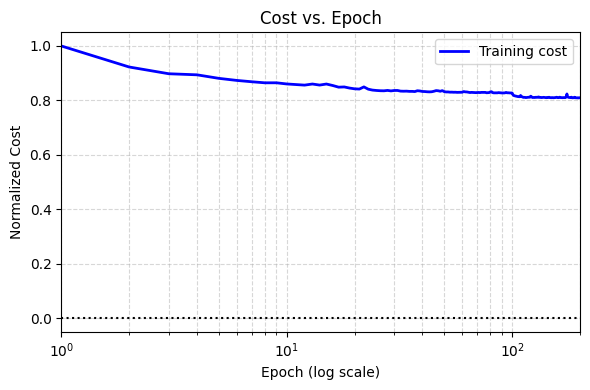

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose train_loss_list holds your summed-MSE for each epoch
# and val_psnr_list/val_ssim_list hold your validation metrics.
# If you want validation *loss*, you’ll need to compute it similarly.

epochs = np.arange(1, len(train_loss_list) + 1)

# 1) Normalize training loss to start at 1.0
init_cost = train_loss_list[0]
norm_train = [c / init_cost for c in train_loss_list]

# (Optional) If you have a validation loss list, normalize that too:
# norm_val = [c / init_cost for c in val_loss_list]

plt.figure(figsize=(6,4))

# 2) Plot on a log-x axis to mimic “senior style” spacing
plt.semilogx(epochs, norm_train, 'b-', linewidth=2, label='Training cost')
# plt.semilogx(epochs, norm_val, 'r--', linewidth=2, label='Validation cost')

# 3) Draw a horizontal line at zero (or at your minimal plateau)
plt.hlines(0, epochs[0], epochs[-1], colors='k', linestyles='dotted')

plt.title("Cost vs. Epoch")
plt.xlabel("Epoch (log scale)")
plt.ylabel("Normalized Cost")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.xlim(1, epochs[-1])
plt.legend()
plt.tight_layout()
plt.show()


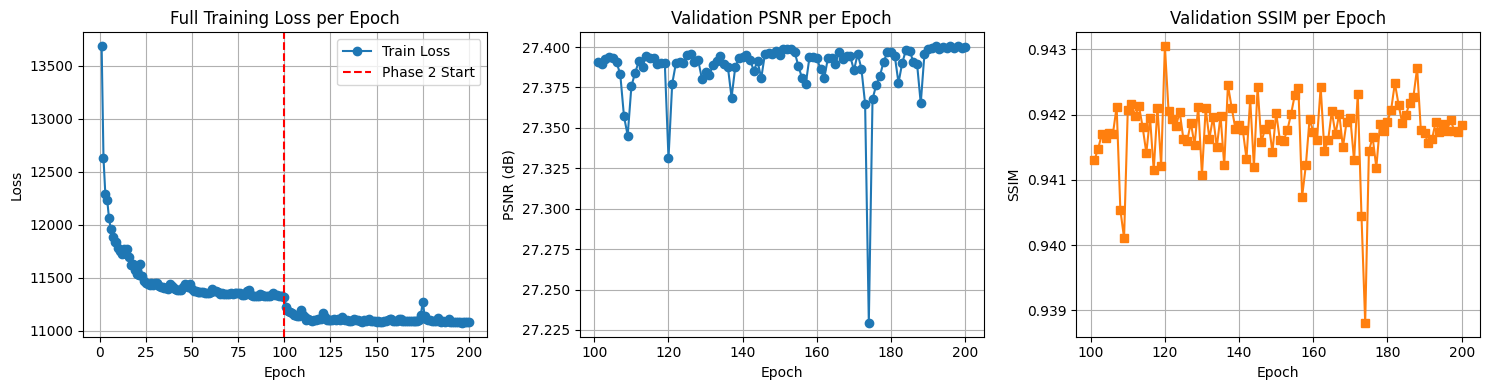

In [18]:
# Ensure we have at least one Phase 2 epoch’s worth of data
if len(val_psnr_list) == 0:
    print("No Phase 2 data yet—run some training epochs first.")
else:
    # --- MODIFIED: Calculate epoch counts for both phases ---
    n_p2 = len(val_psnr_list)
    n_p1 = len(train_loss_list) - n_p2

    # --- MODIFIED: Create x-axes for total training and for Phase 2 ---
    x_total = list(range(1, n_p1 + n_p2 + 1))
    x_p2    = list(range(n_p1 + 1, n_p1 + n_p2 + 1))
    
    y_train = train_loss_list
    y_psnr  = val_psnr_list
    y_ssim  = val_ssim_list
    #y_train[0] = 21113.05

    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 4))

    # 1) Training Loss (Both Phases)
    plt.subplot(1, 3, 1)
    plt.plot(x_total, y_train, 'o-', label='Train Loss')
    
    # --- ADDED: Add a vertical line to show where Phase 2 begins ---
    plt.axvline(x=n_p1, color='r', linestyle='--', label='Phase 2 Start')
    
    plt.title("Full Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 2) Validation PSNR (Phase 2)
    plt.subplot(1, 3, 2)
    # --- MODIFIED: Use the correct x-axis for Phase 2 data ---
    plt.plot(x_p2, y_psnr, 'o-', color='tab:blue')
    plt.title("Validation PSNR per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.grid(True)

    # 3) Validation SSIM (Phase 2)
    plt.subplot(1, 3, 3)
    # --- MODIFIED: Use the correct x-axis for Phase 2 data ---
    plt.plot(x_p2, y_ssim, 's-', color='tab:orange')
    plt.title("Validation SSIM per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("SSIM")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

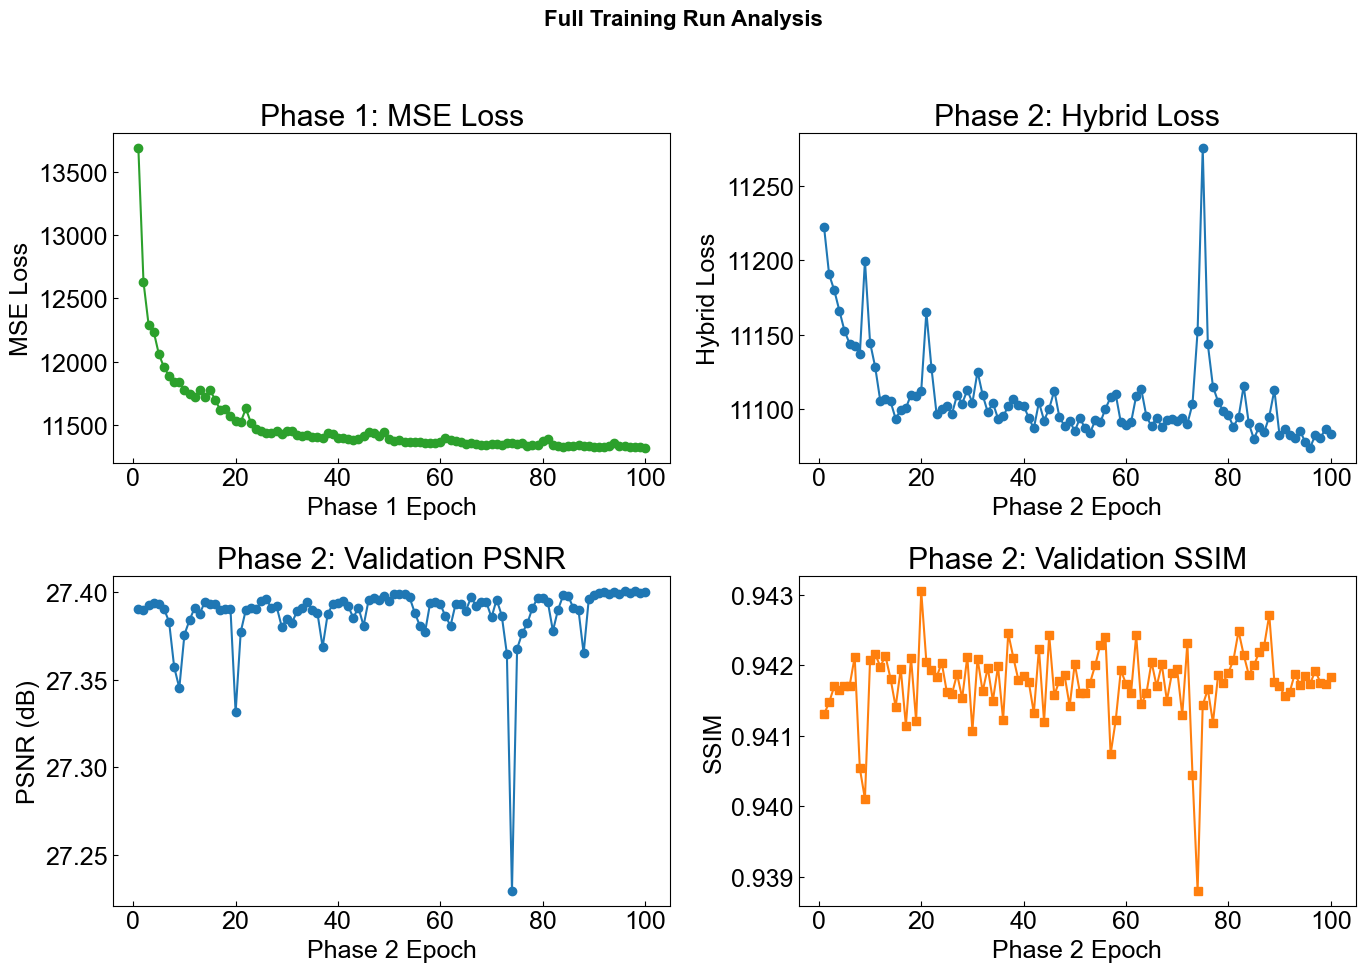

In [19]:
# Ensure we have at least one Phase 2 epoch’s worth of data
if len(val_psnr_list) == 0:
    print("No Phase 2 data yet—run some training epochs first.")
else:
    # --- DATA PREPARATION (This part is unchanged) ---
    # Calculate epoch counts for both phases
    n_p2 = len(val_psnr_list)
    n_p1 = len(train_loss_list) - n_p2

    # Create x-axes for each phase
    x_p1 = list(range(1, n_p1 + 1))
    x_p2 = list(range(1, n_p2 + 1))

    # Separate the training loss data for each phase
    y_train_p1 = train_loss_list[:n_p1]
    y_train_p2 = train_loss_list[n_p1:]
    
    y_psnr = val_psnr_list
    y_ssim = val_ssim_list

    import matplotlib.pyplot as plt

    # --- PLOTTING (New 2x2 Layout) ---
    # Adjust figure size for a more square-like grid
    plt.figure(figsize=(14, 10))
    plt.suptitle("Full Training Run Analysis", fontsize=16, fontweight='bold')
    plt.rcParams["font.size"]=18
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.sans-serif"] = ["Arial"]
    
    # --- Plot 1: Phase 1 Training Loss ---
    plt.subplot(2, 2, 1)
    plt.plot(x_p1, y_train_p1, 'o-', color='tab:green')
    plt.title("Phase 1: MSE Loss")
    plt.xlabel("Phase 1 Epoch")
    plt.ylabel("MSE Loss")
    plt.tick_params(direction="in")
    plt.grid(False)

    # --- Plot 2: Phase 2 Training Loss ---
    plt.subplot(2, 2, 2)
    plt.plot(x_p2, y_train_p2, 'o-')
    plt.title("Phase 2: Hybrid Loss")
    plt.xlabel("Phase 2 Epoch")
    plt.ylabel("Hybrid Loss")
    plt.tick_params(direction="in")
    plt.grid(False)

    # --- Plot 3: Validation PSNR ---
    plt.subplot(2, 2, 3)
    plt.plot(x_p2, y_psnr, 'o-', color='tab:blue')
    plt.title("Phase 2: Validation PSNR")
    plt.xlabel("Phase 2 Epoch")
    plt.ylabel("PSNR (dB)")
    plt.tick_params(direction="in")
    plt.grid(False)

    # --- Plot 4: Validation SSIM ---
    plt.subplot(2, 2, 4)
    plt.plot(x_p2, y_ssim, 's-', color='tab:orange')
    plt.title("Phase 2: Validation SSIM")
    plt.xlabel("Phase 2 Epoch")
    plt.ylabel("SSIM")
    plt.tick_params(direction="in")
    plt.grid(False)

    # Adjust layout and show the plots
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
    plt.show()

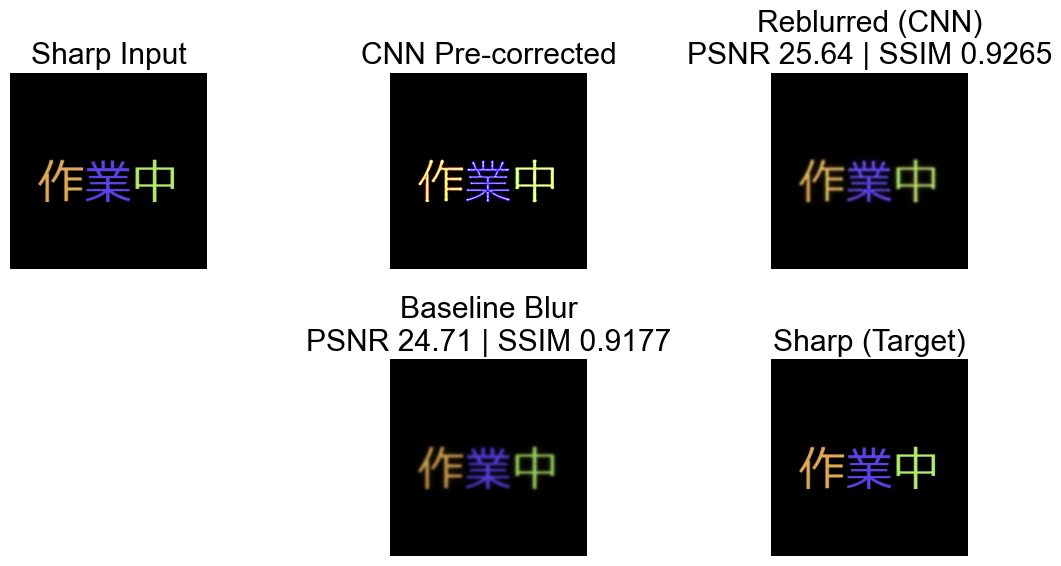

CNN   →  PSNR 25.64 dB   |   SSIM 0.9265
Blur  →  PSNR 24.71 dB   |   SSIM 0.9177


In [20]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from math import log10
from torchmetrics.functional.image import structural_similarity_index_measure as ssim

# === Grab one batch of sharp images from your validation loader ===
sharp_batch = next(iter(val_loader)).to(device)  # no more comma‐underscore

# === Predict with CNN and simulate blur ===
model.eval()
with torch.no_grad():
    # Pre-correct (model outputs a residual, so clamp to [0,1] full image)
    precorr    = torch.clamp(model(sharp_batch), 0.0, 1.0)
    # Re-blur the model’s output
    reblurred  = reblur_tensor(precorr, kernel_tensor)
    # Baseline: plain blur of the original sharp
    baseline   = reblur_tensor(sharp_batch, kernel_tensor)

# === Metric functions ===
def psnr(a, b, eps=1e-8):
    mse = torch.mean((a - b) ** 2)
    return -10 * torch.log10(mse + eps)

def ssim_metric(a, b):
    return ssim(a, b, data_range=1.0)

# === Pick a sample to visualize ===
idx = 0  # or any index < batch_size
sharp_img   = sharp_batch[idx].cpu()
precorr_img = precorr   [idx].cpu()
cnn_img     = reblurred [idx].cpu()
base_img    = baseline  [idx].cpu()

# === Compute PSNR & SSIM ===
psnr_cnn  = psnr(cnn_img,  sharp_img).item()
ssim_cnn  = ssim_metric(cnn_img.unsqueeze(0),  sharp_img.unsqueeze(0)).item()
psnr_base = psnr(base_img, sharp_img).item()
ssim_base = ssim_metric(base_img.unsqueeze(0), sharp_img.unsqueeze(0)).item()

# === Plot ===
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(TF.to_pil_image(sharp_img))
plt.title("Sharp Input")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(TF.to_pil_image(precorr_img))
plt.title("CNN Pre-corrected")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(TF.to_pil_image(cnn_img))
plt.title(f"Reblurred (CNN)\nPSNR {psnr_cnn:.2f} | SSIM {ssim_cnn:.4f}")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(TF.to_pil_image(base_img))
plt.title(f"Baseline Blur\nPSNR {psnr_base:.2f} | SSIM {ssim_base:.4f}")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(TF.to_pil_image(sharp_img))
plt.title("Sharp (Target)")
plt.axis("off")

plt.tight_layout()
plt.show()

# And print for easy logging:
print(f"CNN   →  PSNR {psnr_cnn:.2f} dB   |   SSIM {ssim_cnn:.4f}")
print(f"Blur  →  PSNR {psnr_base:.2f} dB   |   SSIM {ssim_base:.4f}")


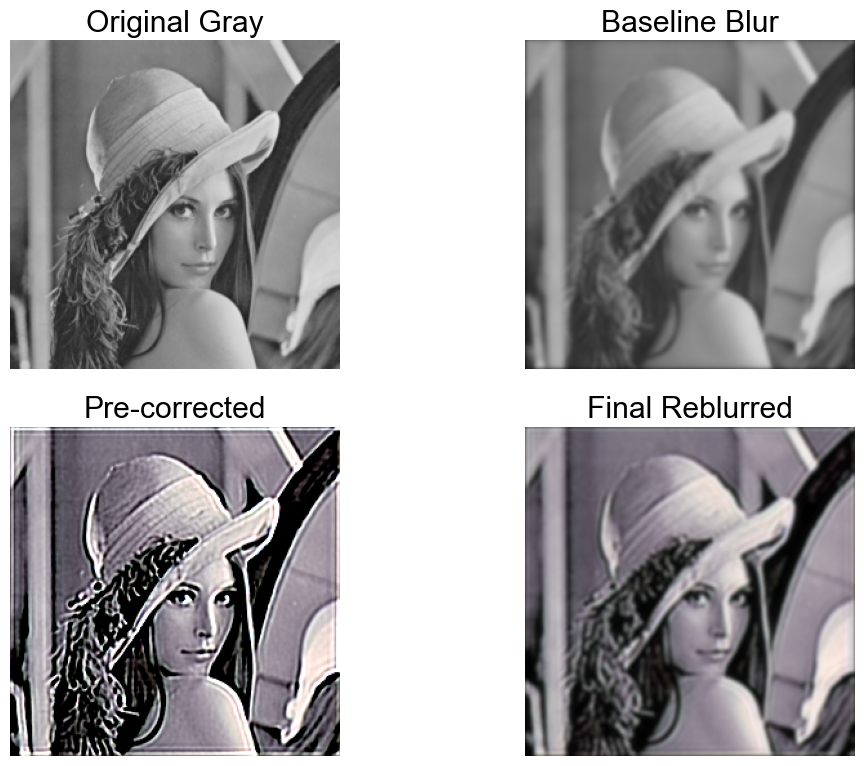

In [21]:
import os
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image

# === Paths & setup ===
root      = r"C:\AI_research"
img_path  = os.path.join(root, "dataset", "test", "lena.png")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size  = 256

# === 1) Load & preprocess as grayscale ===
gray_pil = Image.open(img_path).convert("L")     # single‐channel
gray_rgb = gray_pil.convert("RGB")               # copy into R=G=B
transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor()
])
sharp_in = transform(gray_rgb).unsqueeze(0).to(device)  # [1,3,256,256]

# === 2) Model + blur ===
model.eval()
with torch.no_grad():
    precorr       = torch.clamp(model(sharp_in), 0., 1.)
    final_reblur  = reblur_tensor(precorr, kernel_tensor)
    baseline_blur = reblur_tensor(sharp_in, kernel_tensor)

# === 3) Convert back to CPU tensors ===
orig_img     = sharp_in    .squeeze(0).cpu()
baseline_img = baseline_blur.squeeze(0).cpu()
precorr_img  = precorr     .squeeze(0).cpu()
final_img    = final_reblur.squeeze(0).cpu()

# === 4) Plot 2×2 grid ===
titles = ["Original Gray", "Baseline Blur", "Pre-corrected", "Final Reblurred"]
images = [orig_img, baseline_img, precorr_img, final_img]

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate(zip(images, titles), 1):
    ax = plt.subplot(2, 2, i)
    ax.imshow(TF.to_pil_image(img), cmap="gray" if i == 1 else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

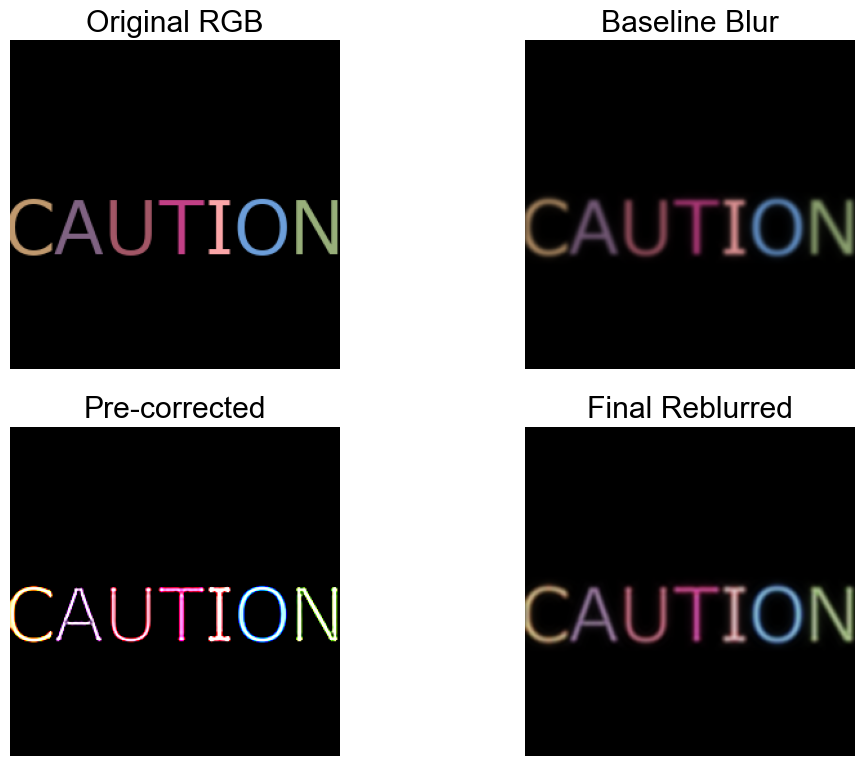

Baseline Blur  → PSNR: 25.92 dB, SSIM: 0.9074
Final Reblurred→ PSNR: 27.80 dB, SSIM: 0.9200


In [22]:
import os
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image

# === Paths & setup ===
root      = r"C:\AI_research"
img_path  = os.path.join(root, "dataset", "test", "signage.png")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size  = 256

# === 1) Load & preprocess as full‐color RGB ===
sharp_pil = Image.open(img_path).convert("RGB")      # color load
transform  = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor()
])
sharp_in   = transform(sharp_pil).unsqueeze(0).to(device)  # [1,3,256,256]

# === 2) Model + blur ===
model.eval()
with torch.no_grad():
    precorr       = torch.clamp(model(sharp_in), 0., 1.)
    final_reblur  = reblur_tensor(precorr, kernel_tensor)
    baseline_blur = reblur_tensor(sharp_in,  kernel_tensor)

# === 3) Convert back to CPU tensors ===
orig_img     = sharp_in    .squeeze(0).cpu()
baseline_img = baseline_blur.squeeze(0).cpu()
precorr_img  = precorr     .squeeze(0).cpu()
final_img    = final_reblur.squeeze(0).cpu()

# === 4) Plot 2×2 grid ===
titles = ["Original RGB", "Baseline Blur", "Pre-corrected", "Final Reblurred"]
images = [orig_img, baseline_img, precorr_img, final_img]

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate(zip(images, titles), 1):
    ax = plt.subplot(2, 2, i)
    ax.imshow(TF.to_pil_image(img))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

#calculate PSNR & SSIM
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

def tensor_to_numpy(img):
    # img: torch tensor (3,H,W), values 0-1
    np_img = img.detach().cpu().numpy()
    np_img = np.transpose(np_img, (1, 2, 0))  # HWC
    return np_img

# Convert all images to numpy (H,W,C) and float32
sharp_np     = tensor_to_numpy(orig_img)
blur_np      = tensor_to_numpy(baseline_img)
precorr_np   = tensor_to_numpy(precorr_img)
final_np     = tensor_to_numpy(final_img)

# --- PSNR/SSIM for Baseline Blur ---
psnr_blur = peak_signal_noise_ratio(sharp_np, blur_np, data_range=1.0)
ssim_blur = structural_similarity(sharp_np, blur_np, data_range=1.0, channel_axis=2)

# --- PSNR/SSIM for Final Reblurred (pre-corrected + blur) ---
psnr_final = peak_signal_noise_ratio(sharp_np, final_np, data_range=1.0)
ssim_final = structural_similarity(sharp_np, final_np, data_range=1.0, channel_axis=2)

print(f"Baseline Blur  → PSNR: {psnr_blur:.2f} dB, SSIM: {ssim_blur:.4f}")
print(f"Final Reblurred→ PSNR: {psnr_final:.2f} dB, SSIM: {ssim_final:.4f}")


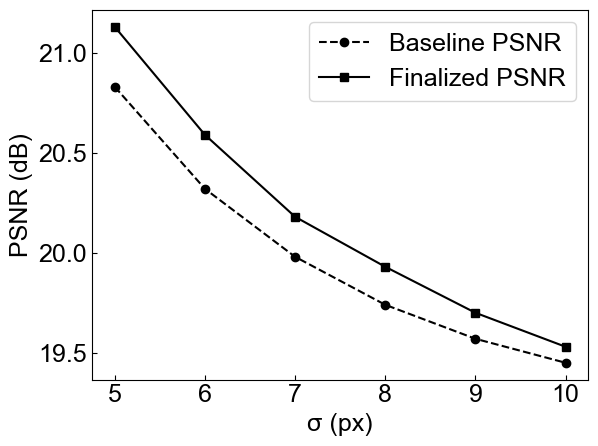

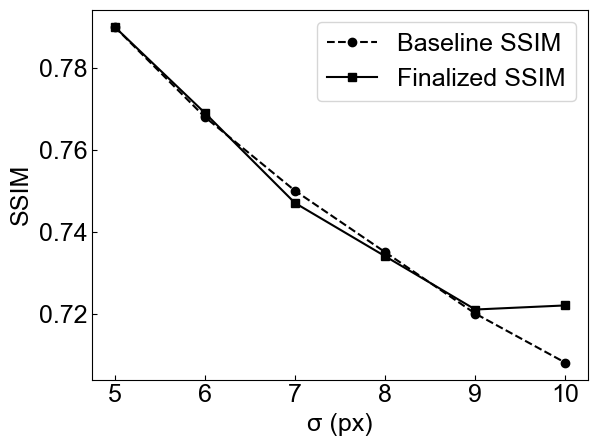

In [23]:
import matplotlib.pyplot as plt

# 1) Encode your table as Python lists
sigma            = [5, 6, 7, 8, 9, 10]
baseline_psnr    = [20.83, 20.32, 19.98, 19.74, 19.57, 19.45]
finalized_psnr   = [21.13, 20.59, 20.18, 19.93, 19.70, 19.53]

baseline_ssim    = [0.79, 0.768, 0.75, 0.735, 0.72, 0.708]
finalized_ssim   = [0.79, 0.769, 0.747, 0.734, 0.721, 0.722]

plt.rcParams["font.size"]=18
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]

# 2) Plot PSNR
plt.figure()
plt.plot(sigma, baseline_psnr, marker='o', label='Baseline PSNR',linestyle='--', color='black',)
plt.plot(sigma, finalized_psnr, marker='s', label='Finalized PSNR' ,color='black',)
plt.xlabel('σ (px)')
plt.ylabel('PSNR (dB)')
plt.legend()
plt.grid(False)
plt.tick_params(direction="in")
plt.show()

# 3) Plot SSIM
plt.figure()
plt.plot(sigma, baseline_ssim, marker='o', label='Baseline SSIM',linestyle='--', color='black',)
plt.plot(sigma, finalized_ssim, marker='s', label='Finalized SSIM', color='black',)
plt.xlabel('σ (px)')
plt.ylabel('SSIM')
plt.legend()
plt.grid(False)
plt.tick_params(direction="in")
plt.show()